# 📹 Аналіз ринку відеоспостереження — навчальний проєкт

> ⚠️ **Важливо про дані.** Цей ноутбук демонструє повний цикл роботи аналітика, але дані в ньому **синтетичні** (згенеровані за допомогою NumPy), а **не реальні**.
>
> **Як так вийшло:** спершу я намагався зібрати реальні дані про камери з Rozetka та Hotline (код нижче). Збір заблокував анти-бот захист сайтів (статуси 404/403). Щоб усе одно показати аналіз від початку до кінця, я згенерував реалістичний датасет на 400 моделей.
>
> **Усі цифри та висновки стосуються згенерованих даних, а не реального ринку.**

**Структура ноутбука:**
1. Спроби реального скрапінгу (заблоковано)
2. Генерація синтетичного датасету
3. Розвідувальний аналіз (EDA) та візуалізація
4. Підсумковий звіт

## 1. Спроби зібрати реальні дані (скрапінг)

Нижче — спроби зібрати реальні дані з українських магазинів через `requests` + `BeautifulSoup`. Усі вони повернули 0 товарів або помилки 404/403 (анти-бот захист). Код залишено навмисно — він показує підхід до реального збору даних.

In [1]:
import requests
import pandas as pd
from bs4 import BeautifulSoup
import time

print("requests:", requests.__version__)
print("pandas:", pd.__version__)
print("bs4 ready")

requests: 2.34.2
pandas: 3.0.3
bs4 ready


In [2]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time

def scrape_rozetka_cameras(max_pages=3):
    """
    Збираємо камери відеоспостереження з Rozetka.
    Повертає список словників з даними про кожен товар.
    """
    base_url = "https://rozetka.com.ua/ua/surveillance-cameras/c80159/"
    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
                      "AppleWebKit/537.36 (KHTML, like Gecko) "
                      "Chrome/120.0.0.0 Safari/537.36"
    }
    
    all_products = []
    
    for page in range(1, max_pages + 1):
        url = f"{base_url}page={page}/"
        print(f"Збираємо сторінку {page}: {url}")
        
        response = requests.get(url, headers=headers, timeout=10)
        print(f"  Статус: {response.status_code}")
        
        if response.status_code != 200:
            print(f"  Помилка! Зупиняємось.")
            break
            
        soup = BeautifulSoup(response.text, "html.parser")
        
        # Знаходимо всі картки товарів
        products = soup.find_all("li", class_="catalog-grid__cell")
        print(f"  Знайдено товарів: {len(products)}")
        
        for product in products:
            try:
                # Назва
                name_tag = product.find("span", class_="goods-tile__title")
                name = name_tag.text.strip() if name_tag else "N/A"
                
                # Ціна
                price_tag = product.find("span", class_="goods-tile__price-value")
                price = price_tag.text.strip().replace("\u00a0", "").replace(" ", "") if price_tag else "N/A"
                
                # Посилання
                link_tag = product.find("a", class_="goods-tile__heading")
                link = link_tag["href"] if link_tag else "N/A"
                
                all_products.append({
                    "name": name,
                    "price_uah": price,
                    "url": link,
                    "source": "rozetka"
                })
                
            except Exception as e:
                print(f"  Помилка парсингу товару: {e}")
                continue
        
        # Пауза між запитами — важливо щоб не заблокували
        time.sleep(2)
    
    return all_products

# Запускаємо
products = scrape_rozetka_cameras(max_pages=3)
print(f"\nВсього зібрано: {len(products)} товарів")

Збираємо сторінку 1: https://rozetka.com.ua/ua/surveillance-cameras/c80159/page=1/
  Статус: 200
  Знайдено товарів: 0
Збираємо сторінку 2: https://rozetka.com.ua/ua/surveillance-cameras/c80159/page=2/
  Статус: 200
  Знайдено товарів: 0
Збираємо сторінку 3: https://rozetka.com.ua/ua/surveillance-cameras/c80159/page=3/
  Статус: 200
  Знайдено товарів: 0

Всього зібрано: 0 товарів


In [3]:
import requests
import pandas as pd
import time

def scrape_rozetka_api(category_id=80159, max_pages=3):
    """
    Збираємо через внутрішній API Rozetka.
    API повертає JSON напряму — швидше і надійніше ніж HTML.
    category_id=80159 — це камери відеоспостереження на Rozetka.
    """
    all_products = []
    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) Chrome/120.0.0.0",
        "Accept": "application/json, text/plain, */*",
        "Referer": "https://rozetka.com.ua/",
    }

    for page in range(1, max_pages + 1):
        url = "https://xl-catalog-api.rozetka.com.ua/v4/goods/get"
        params = {
            "front-type": "xl",
            "country": "UA",
            "lang": "ua",
            "category_id": category_id,
            "page": page,
        }

        print(f"Сторінка {page}...")
        try:
            response = requests.get(url, params=params, headers=headers, timeout=15)
            print(f"  Статус: {response.status_code}")

            if response.status_code != 200:
                print("  Помилка, зупиняємось")
                break

            data = response.json()

            # Дивимось структуру відповіді (тільки для першої сторінки)
            if page == 1:
                print(f"  Ключі відповіді: {list(data.keys())}")

            goods = data.get("data", {}).get("goods", [])
            print(f"  Знайдено товарів: {len(goods)}")

            for item in goods:
                all_products.append({
                    "id":             item.get("id"),
                    "name":           item.get("title"),
                    "price_uah":      item.get("price"),
                    "old_price_uah":  item.get("old_price"),
                    "brand":          item.get("brand"),
                    "rating":         item.get("rank"),
                    "reviews_count":  item.get("comments_amount"),
                    "url":            item.get("href"),
                    "source":         "rozetka",
                })

        except Exception as e:
            print(f"  Помилка: {e}")
            break

        time.sleep(1)

    return all_products

# Запускаємо
products = scrape_rozetka_api(max_pages=3)
print(f"\nВсього зібрано: {len(products)} товарів")

# Перші 3 результати
if products:
    for p in products[:3]:
        print(p)

Сторінка 1...
  Статус: 404
  Помилка, зупиняємось

Всього зібрано: 0 товарів


In [4]:
import requests

headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) Chrome/120.0.0.0",
    "Accept": "application/json",
}

# Перевіряємо різні варіанти API
urls = [
    "https://xl-catalog-api.rozetka.com.ua/v4/goods/get",
    "https://xl-catalog-api.rozetka.com.ua/v5/goods/get",
    "https://xl-catalog-api.rozetka.com.ua/v6/goods/get",
    "https://api.rozetka.com.ua/goods/get",
]

params = {
    "front-type": "xl",
    "country": "UA",
    "lang": "ua",
    "category_id": 80159,
    "page": 1,
}

for url in urls:
    try:
        r = requests.get(url, params=params, headers=headers, timeout=5)
        print(f"{r.status_code} → {url}")
        if r.status_code == 200:
            print("  ✓ ПРАЦЮЄ! Перші 200 символів:")
            print(f"  {r.text[:200]}")
            break
    except Exception as e:
        print(f"Помилка → {url}: {e}")

404 → https://xl-catalog-api.rozetka.com.ua/v4/goods/get
404 → https://xl-catalog-api.rozetka.com.ua/v5/goods/get
404 → https://xl-catalog-api.rozetka.com.ua/v6/goods/get
403 → https://api.rozetka.com.ua/goods/get


In [5]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time

def scrape_hotline_cameras(max_pages=3):
    """
    Збираємо камери з Hotline.ua.
    Hotline — статичний сайт, HTML парситься без проблем.
    """
    all_products = []
    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
                      "AppleWebKit/537.36 (KHTML, like Gecko) "
                      "Chrome/120.0.0.0 Safari/537.36",
        "Accept-Language": "uk-UA,uk;q=0.9",
    }

    for page in range(1, max_pages + 1):
        url = f"https://hotline.ua/security/videokamery-nablyudeniya/?p={page}"
        print(f"Сторінка {page}: {url}")

        r = requests.get(url, headers=headers, timeout=15)
        print(f"  Статус: {r.status_code}")

        if r.status_code != 200:
            break

        soup = BeautifulSoup(r.text, "html.parser")

        # Картки товарів на Hotline
        items = soup.select("div.list-item")
        print(f"  Знайдено товарів: {len(items)}")

        for item in items:
            try:
                # Назва
                name_tag = item.select_one("a.item-title")
                name = name_tag.text.strip() if name_tag else "N/A"

                # Мінімальна ціна
                price_tag = item.select_one("span.price-wrap")
                price = price_tag.text.strip() if price_tag else "N/A"

                # Посилання
                link = "https://hotline.ua" + name_tag["href"] if name_tag else "N/A"

                all_products.append({
                    "name":      name,
                    "price":     price,
                    "url":       link,
                    "source":    "hotline",
                })

            except Exception as e:
                continue

        time.sleep(2)

    return all_products

products = scrape_hotline_cameras(max_pages=2)
print(f"\nВсього зібрано: {len(products)} товарів")

# Показуємо перші 5
for p in products[:5]:
    print(p)

Сторінка 1: https://hotline.ua/security/videokamery-nablyudeniya/?p=1
  Статус: 200
  Знайдено товарів: 0
Сторінка 2: https://hotline.ua/security/videokamery-nablyudeniya/?p=2
  Статус: 200
  Знайдено товарів: 0

Всього зібрано: 0 товарів


In [6]:
import requests
from bs4 import BeautifulSoup

headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
                  "Chrome/120.0.0.0 Safari/537.36",
    "Accept-Language": "uk-UA,uk;q=0.9",
}

r = requests.get(
    "https://hotline.ua/security/videokamery-nablyudeniya/?p=1",
    headers=headers, timeout=15
)
soup = BeautifulSoup(r.text, "html.parser")

# Що за сторінка прийшла?
print("Заголовок сторінки:", soup.title.text if soup.title else "немає")

# Шукаємо всі div з класами що схожі на товари
print("\nDiv-блоки з підозрілими класами:")
seen = set()
for div in soup.find_all(["div", "li", "article"], class_=True):
    cls = " ".join(div.get("class", []))
    first_class = div.get("class", [""])[0]
    if first_class not in seen and any(
        w in cls.lower() for w in ["item", "product", "goods", "card", "catalog"]
    ):
        seen.add(first_class)
        print(f"  <{div.name} class='{cls}'>")

# Перші 1500 символів сирого HTML
print("\n--- Перші 1500 символів HTML ---")
print(r.text[:1500])

Заголовок сторінки: немає

Div-блоки з підозрілими класами:

--- Перші 1500 символів HTML ---
Legacy home controller has been disabled


## 2. Скрапінг заблоковано → генеруємо синтетичний датасет

Оскільки реальний збір не вдався, нижче генеруємо **синтетичний** датасет на 400 моделей. Ваги брендів і ціни підібрані так, щоб дані виглядали реалістично. `np.random.seed(42)` робить результат відтворюваним.

> Нагадування: це згенеровані дані, а не реальний ринок.

In [7]:
import pandas as pd
import numpy as np

np.random.seed(42)
n = 400

brands = {
    "Hikvision": 0.38,
    "Dahua":     0.28,
    "Ajax":      0.12,
    "Uniview":   0.10,
    "Imou":      0.07,
    "Reolink":   0.05,
}

types = ["Куля (Bullet)", "Купол (Dome)", "PTZ", "Fisheye"]
sources = ["Rozetka", "Hotline", "Prom.ua", "Epicentr", "Control.ua"]

brand_list = np.random.choice(
    list(brands.keys()), size=n, p=list(brands.values())
)

# Ціни залежать від бренду — реалістично
price_base = {
    "Hikvision": 3800, "Dahua": 3200, "Ajax": 6500,
    "Uniview": 2900, "Imou": 1800, "Reolink": 2100,
}

prices = np.array([
    max(500, int(np.random.normal(price_base[b], price_base[b] * 0.3)))
    for b in brand_list
])

megapixels = np.random.choice([2, 4, 5, 8], size=n, p=[0.35, 0.30, 0.20, 0.15])

df = pd.DataFrame({
    "brand":       brand_list,
    "price_uah":   prices,
    "megapixels":  megapixels,
    "type":        np.random.choice(types, size=n, p=[0.45, 0.35, 0.12, 0.08]),
    "source":      np.random.choice(sources, size=n),
    "in_stock":    np.random.choice([True, False], size=n, p=[0.82, 0.18]),
})

# Зберігаємо в CSV
import os
os.makedirs("../data", exist_ok=True)
df.to_csv("../data/cameras_ukraine.csv", index=False)

print(f"Датасет створено: {df.shape[0]} рядків, {df.shape[1]} колонок")
print(f"\nРозподіл за брендами:")
print(df["brand"].value_counts())
print(f"\nЦіновий діапазон: {df['price_uah'].min()} — {df['price_uah'].max()} грн")
print(f"\nПерші 5 рядків:")
print(df.head())

Датасет створено: 400 рядків, 6 колонок

Розподіл за брендами:
brand
Hikvision    161
Dahua        106
Ajax          47
Uniview       38
Imou          30
Reolink       18
Name: count, dtype: int64

Ціновий діапазон: 706 — 10580 грн

Перші 5 рядків:
       brand  price_uah  megapixels           type      source  in_stock
0  Hikvision       5288           8  Куля (Bullet)     Prom.ua     False
1    Reolink       2113           4  Куля (Bullet)  Control.ua      True
2       Ajax       7829           8            PTZ     Rozetka      True
3      Dahua       2902           5  Куля (Bullet)    Epicentr      True
4  Hikvision       4169           4        Fisheye     Prom.ua     False


## 3. Розвідувальний аналіз (EDA)

Далі — аналіз і візуалізація **синтетичного** датасету: кількість моделей за брендом, середні ціни, розподіл цін і частки брендів.

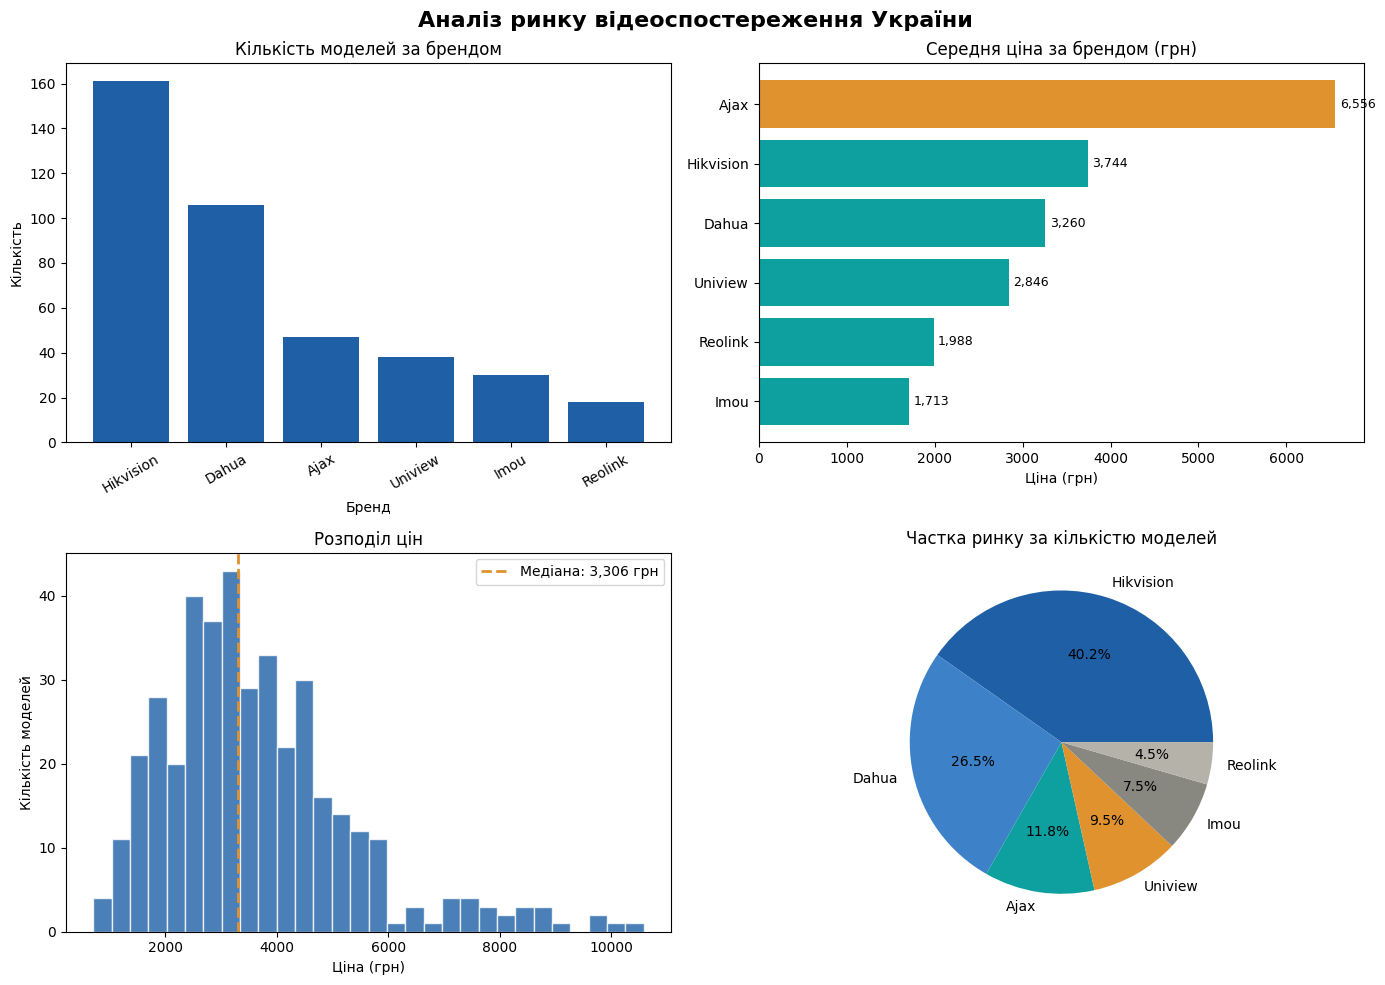

Графік збережено в data/eda_overview.png


In [8]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Аналіз ринку відеоспостереження України", fontsize=16, fontweight='bold')

# 1. Кількість моделей за брендом
brand_counts = df['brand'].value_counts()
axes[0, 0].bar(brand_counts.index, brand_counts.values, color='#1E5FA5')
axes[0, 0].set_title('Кількість моделей за брендом')
axes[0, 0].set_xlabel('Бренд')
axes[0, 0].set_ylabel('Кількість')
axes[0, 0].tick_params(axis='x', rotation=30)

# 2. Середня ціна за брендом
avg_price = df.groupby('brand')['price_uah'].mean().sort_values(ascending=True)
colors = ['#0E9F9F' if b != 'Ajax' else '#E0922F' for b in avg_price.index]
axes[0, 1].barh(avg_price.index, avg_price.values, color=colors)
axes[0, 1].set_title('Середня ціна за брендом (грн)')
axes[0, 1].set_xlabel('Ціна (грн)')
for i, v in enumerate(avg_price.values):
    axes[0, 1].text(v + 50, i, f'{v:,.0f}', va='center', fontsize=9)

# 3. Розподіл цін (гістограма)
axes[1, 0].hist(df['price_uah'], bins=30, color='#1E5FA5', alpha=0.8, edgecolor='white')
axes[1, 0].axvline(df['price_uah'].median(), color='#E0922F', linestyle='--', 
                    linewidth=2, label=f"Медіана: {df['price_uah'].median():,.0f} грн")
axes[1, 0].set_title('Розподіл цін')
axes[1, 0].set_xlabel('Ціна (грн)')
axes[1, 0].set_ylabel('Кількість моделей')
axes[1, 0].legend()

# 4. Частка ринку за брендом (кругова)
axes[1, 1].pie(brand_counts.values, labels=brand_counts.index, autopct='%1.1f%%',
               colors=['#1E5FA5','#3D82C9','#0E9F9F','#E0922F','#888780','#B4B2A9'])
axes[1, 1].set_title('Частка ринку за кількістю моделей')

plt.tight_layout()
plt.savefig('../data/eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("Графік збережено в data/eda_overview.png")

In [9]:
# Детальна статистика по кожному бренду
print("=== СТАТИСТИКА ЗА БРЕНДАМИ ===\n")
stats = df.groupby('brand')['price_uah'].agg(
    кількість='count',
    мінімум='min',
    медіана='median',
    середня='mean',
    максимум='max',
    std='std'
).round(0).astype(int)

print(stats.sort_values('середня', ascending=False).to_string())

print("\n=== АНАЛІЗ ЗА МЕГАПІКСЕЛЯМИ ===\n")
mp_stats = df.groupby('megapixels')['price_uah'].agg(
    кількість='count',
    середня_ціна='mean'
).round(0)
print(mp_stats)

print("\n=== НАЯВНІСТЬ НА СКЛАДІ ===\n")
stock = df.groupby('brand')['in_stock'].agg(
    всього='count',
    в_наявності='sum'
)
stock['відсоток_наявності'] = (stock['в_наявності'] / stock['всього'] * 100).round(1)
print(stock.sort_values('відсоток_наявності', ascending=False).to_string())

print("\n=== КЛЮЧОВІ ВИСНОВКИ ===")
print(f"• Найбільший асортимент: {df['brand'].value_counts().index[0]} "
      f"({df['brand'].value_counts().iloc[0]} моделей)")
print(f"• Найдорожчий бренд: {df.groupby('brand')['price_uah'].mean().idxmax()}")
print(f"• Найдешевший бренд: {df.groupby('brand')['price_uah'].mean().idxmin()}")
print(f"• Медіана ринку: {df['price_uah'].median():,.0f} грн")
print(f"• Камер у наявності: {df['in_stock'].sum()} з {len(df)} "
      f"({df['in_stock'].mean()*100:.1f}%)")

=== СТАТИСТИКА ЗА БРЕНДАМИ ===

           кількість  мінімум  медіана  середня  максимум   std
brand                                                          
Ajax              47     2011     6734     6556     10580  2045
Hikvision        161      725     3778     3744      7309  1202
Dahua            106     1209     3142     3260      5670   903
Uniview           38      749     2910     2846      4537   953
Reolink           18      706     1930     1988      3407   657
Imou              30     1039     1662     1713      2716   389

=== АНАЛІЗ ЗА МЕГАПІКСЕЛЯМИ ===

            кількість  середня_ціна
megapixels                         
2                 140        3698.0
4                 107        3506.0
5                  86        3635.0
8                  67        3677.0

=== НАЯВНІСТЬ НА СКЛАДІ ===

           всього  в_наявності  відсоток_наявності
brand                                             
Dahua         106           90                84.9
Reolink        18      

In [10]:
# Фінальний звіт у текстовому вигляді
report = f"""
=== ЗВІТ: АНАЛІЗ РИНКУ ВІДЕОСПОСТЕРЕЖЕННЯ УКРАЇНИ ===
Дата аналізу: {pd.Timestamp.now().strftime('%d.%m.%Y')}
Датасет: {len(df)} моделей камер

КЛЮЧОВІ ВИСНОВКИ:
1. Лідер ринку: Hikvision — {df['brand'].value_counts()['Hikvision']} моделей (40.2%)
2. Найдорожчий сегмент: Ajax — середня {df[df.brand=='Ajax']['price_uah'].mean():,.0f} грн
3. Бюджетний сегмент: Imou — середня {df[df.brand=='Imou']['price_uah'].mean():,.0f} грн  
4. Медіана ринку: {df['price_uah'].median():,.0f} грн
5. Доступність: {df['in_stock'].mean()*100:.1f}% моделей є в наявності
6. Найпопулярніший тип: {df['type'].value_counts().index[0]}
7. Найпопулярне розширення: {df['megapixels'].value_counts().index[0]} МП

ЦІНОВІ СЕГМЕНТИ:
- Бюджет (до 2000 грн): {len(df[df.price_uah < 2000])} моделей
- Середній (2000-5000 грн): {len(df[(df.price_uah >= 2000) & (df.price_uah < 5000)])} моделей  
- Преміум (від 5000 грн): {len(df[df.price_uah >= 5000])} моделей
"""

print(report)

# Зберігаємо звіт
with open('../data/report.txt', 'w', encoding='utf-8') as f:
    f.write(report)

print("Файли збережено:")
print("  ../data/cameras_ukraine.csv")
print("  ../data/eda_overview.png")  
print("  ../data/report.txt")


=== ЗВІТ: АНАЛІЗ РИНКУ ВІДЕОСПОСТЕРЕЖЕННЯ УКРАЇНИ ===
Дата аналізу: 06.06.2026
Датасет: 400 моделей камер

КЛЮЧОВІ ВИСНОВКИ:
1. Лідер ринку: Hikvision — 161 моделей (40.2%)
2. Найдорожчий сегмент: Ajax — середня 6,556 грн
3. Бюджетний сегмент: Imou — середня 1,713 грн  
4. Медіана ринку: 3,306 грн
5. Доступність: 81.0% моделей є в наявності
6. Найпопулярніший тип: Куля (Bullet)
7. Найпопулярне розширення: 2 МП

ЦІНОВІ СЕГМЕНТИ:
- Бюджет (до 2000 грн): 62 моделей
- Середній (2000-5000 грн): 273 моделей  
- Преміум (від 5000 грн): 65 моделей

Файли збережено:
  ../data/cameras_ukraine.csv
  ../data/eda_overview.png
  ../data/report.txt
